In [18]:
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [24]:
NOTEBOOKS_FOLDER = Path.cwd()
PROJECT_ROOT = NOTEBOOKS_FOLDER.parent
DATA_FOLDER = PROJECT_ROOT / "data"
PLOTS_FOLDER = DATA_FOLDER / "plots"

In [2]:
# a2i2: artificial analysis intelligence index
# treat as a 
model_to_a2i2 = {
    "llama_3.1_8b": 12,
    "olmo2_7b": 9,
    "claude_3_haiku": 9,
    "gpt_4o_mini": 13,
    "llama_3.3_70b": 14,
    "phi_4": 13,
    "llama_4_scout": 13,
    "o3": 41,
    "claude_3.7_sonnet": 35,
    "deepseek_r1": 27,
    "gpt_4o": 19,
    "gemini_2.5_flash": 27,
    "gpt_4.1": 26,
    "gemini_2.5_pro": 30,
    "gpt_5_mini": 39,
    "gpt_5.2": 47,
}

In [3]:
lic_paper_results = {
    "tasks": ["code", "database", "actions", "data_to_text", "math", "summary"],
    "models": [
        {
            "model": "llama_3.1_8b",
            "full": [27.4, 64.1, 82.9, 13.7, 63.9, 7.6],
            "concat": [21.2, 47.7, 83.0, 15.7, 62.6, 6.5],
            "sharded": [21.7, 25.9, 45.5, 13.3, 37.4, 3.4],
            "overall_drop_concat": 91.6,
            "overall_drop_sharded": 62.5,
        },
        {
            "model": "olmo2_7b",
            "full": [18.8, 54.8, 56.1, 17.2, 80.0, None],
            "concat": [16.3, 40.5, 49.8, 14.3, 80.1, None],
            "sharded": [14.4, 22.4, 13.8, 9.0, 46.3, None],
            "overall_drop_concat": 86.5,
            "overall_drop_sharded": 50.5,
        },
        {
            "model": "claude_3_haiku",
            "full": [44.8, 85.0, 83.5, 29.8, 73.9, 11.6],
            "concat": [36.3, 76.5, 80.2, 30.1, 76.1, 9.2],
            "sharded": [31.5, 31.8, 55.9, 18.6, 47.1, 1.6],
            "overall_drop_concat": 91.6,
            "overall_drop_sharded": 52.4,
        },
        {
            "model": "gpt_4o_mini",
            "full": [75.9, 89.3, 94.1, 35.9, 88.1, 14.9],
            "concat": [66.7, 90.7, 92.2, 31.2, 88.0, 12.5],
            "sharded": [50.3, 40.2, 52.4, 19.8, 58.7, 7.2],
            "overall_drop_concat": 93.0,
            "overall_drop_sharded": 56.2,
        },
        {
            "model": "llama_3.3_70b",
            "full": [72.0, 91.1, 95.0, 34.1, 91.7, 15.8],
            "concat": [52.7, 87.9, 97.0, 32.0, 91.8, 14.7],
            "sharded": [51.6, 35.4, 71.0, 22.4, 61.5, 10.5],
            "overall_drop_concat": 93.2,
            "overall_drop_sharded": 64.2,
        },
        {
            "model": "phi_4",
            "full": [53.2, 87.6, 82.7, 23.9, 89.2, None],
            "concat": [48.4, 79.6, 76.0, 28.6, 90.4, None],
            "sharded": [39.1, 33.1, 34.1, 23.2, 52.5, None],
            "overall_drop_concat": 99.0,
            "overall_drop_sharded": 61.7,
        },
        {
            "model": "llama_4_scout",
            "full": [73.9, 92.7, 98.0, 35.2, 96.3, 13.7],
            "concat": [60.3, 81.5, 98.3, 28.2, 92.9, 13.7],
            "sharded": [46.4, 27.1, 69.9, 26.1, 67.0, 12.3],
            "overall_drop_concat": 91.0,
            "overall_drop_sharded": 66.1,
        },
        {
            "model": "o3",
            "full": [86.4, 92.0, 89.8, 40.2, 81.6, 30.7],
            "concat": [87.2, 83.3, 91.5, 39.4, 80.0, 30.4],
            "sharded": [53.0, 35.4, 60.2, 21.7, 63.1, 26.5],
            "overall_drop_concat": 98.1,
            "overall_drop_sharded": 64.1,
        },
        {
            "model": "claude_3.7_sonnet",
            "full": [78.0, 93.9, 95.4, 45.6, 85.4, 29.3],
            "concat": [76.2, 81.5, 96.0, 53.3, 87.2, 28.9],
            "sharded": [65.6, 34.9, 33.3, 35.1, 70.0, 23.6],
            "overall_drop_concat": 100.4,
            "overall_drop_sharded": 65.9,
        },
        {
            "model": "deepseek_r1",
            "full": [99.4, 92.1, 97.0, 27.0, 95.5, 26.1],
            "concat": [97.1, 89.9, 97.0, 36.7, 92.9, 24.4],
            "sharded": [70.9, 31.5, 47.5, 20.0, 67.3, 17.2],
            "overall_drop_concat": 103.6,
            "overall_drop_sharded": 60.8,
        },
        {
            "model": "gpt_4o",
            "full": [88.4, 93.6, 96.1, 42.1, 93.8, 23.9],
            "concat": [82.9, 91.7, 97.1, 32.2, 91.9, 23.9],
            "sharded": [61.3, 42.3, 65.0, 20.5, 67.9, 10.6],
            "overall_drop_concat": 94.5,
            "overall_drop_sharded": 57.9,
        },
        {
            "model": "gemini_2.5_flash",
            "full": [97.0, 96.3, 88.4, 51.2, 90.6, 29.1],
            "concat": [92.5, 95.5, 89.2, 51.9, 88.4, 29.4],
            "sharded": [68.3, 51.3, 42.6, 31.0, 66.1, 26.1],
            "overall_drop_concat": 99.3,
            "overall_drop_sharded": 65.8,
        },
        {
            "model": "gpt_4.1",
            "full": [96.6, 93.0, 94.7, 54.6, 91.7, 26.5],
            "concat": [88.7, 86.5, 98.5, 54.4, 89.7, 26.8],
            "sharded": [72.6, 46.0, 62.9, 28.6, 70.7, 13.3],
            "overall_drop_concat": 97.9,
            "overall_drop_sharded": 61.8,
        },
        {
            "model": "gemini_2.5_pro",
            "full": [97.4, 97.3, 97.8, 54.8, 90.2, 31.2],
            "concat": [95.7, 94.9, 98.1, 56.9, 89.3, 31.8],
            "sharded": [68.1, 43.8, 36.3, 46.2, 64.3, 24.9],
            "overall_drop_concat": 100.1,
            "overall_drop_sharded": 64.5,
        },
        # Ad-hoc additions
        {
            "model": "gpt_5_mini",
            # tasks order: [code, database, actions, data_to_text, math, summary]
            "full": [43.3, 86.7, 90.0, None, 86.7, None],
            "concat": [None, None, None, None, None, None],
            "sharded": [48.0, 51.9, 75.8, None, 60.0, None],
            "overall_drop_concat": None,
            "overall_drop_sharded": None,
        },
        {
            "model": "gpt_5.2",
            # tasks order: [code, database, actions, data_to_text, math, summary]
            "full": [97.0, 93.0, 83.0, None, 90.0, None],
            "concat": [None, None, None, None, None, None],
            "sharded": [75.9, 51.0, 50.0, None, 78.6, None],
            "overall_drop_concat": None,
            "overall_drop_sharded": None,
        },
    ],
}

In [4]:
# Build a DataFrame for easier plotting
tasks = lic_paper_results["tasks"]
task_to_idx = {task: i for i, task in enumerate(tasks)}

# Tasks of interest
tasks_of_interest = ["math", "code", "actions", "database"]

# Build data for plotting
plot_data = []
for model_data in lic_paper_results["models"]:
    model = model_data["model"]
    if model not in model_to_a2i2:
        continue
    intelligence = model_to_a2i2[model]
    
    for task in tasks_of_interest:
        idx = task_to_idx[task]
        full_score = model_data["full"][idx]
        sharded_score = model_data["sharded"][idx]
        
        if full_score is None or sharded_score is None or full_score == 0:
            continue
            
        # Proportion of performance retained (sharded / full)
        # Lower = more performance drop
        proportion_retained = sharded_score / full_score
        
        plot_data.append({
            "model": model,
            "task": task,
            "intelligence": intelligence,
            "full": full_score,
            "sharded": sharded_score,
            "proportion_retained": proportion_retained,
        })

df = pd.DataFrame(plot_data)
df.head(10)

,model,task,intelligence,full,sharded,proportion_retained
0,llama_3.1_8b,math,12,63.9,37.4,0.585290
1,llama_3.1_8b,code,12,27.4,21.7,0.791971
2,llama_3.1_8b,actions,12,82.9,45.5,0.548854
3,llama_3.1_8b,database,12,64.1,25.9,0.404056
4,olmo2_7b,math,9,80.0,46.3,0.578750
5,olmo2_7b,code,9,18.8,14.4,0.765957
6,olmo2_7b,actions,9,56.1,13.8,0.245989
7,olmo2_7b,database,9,54.8,22.4,0.408759
8,claude_3_haiku,math,9,73.9,47.1,0.637348
9,claude_3_haiku,code,9,44.8,31.5,0.703125


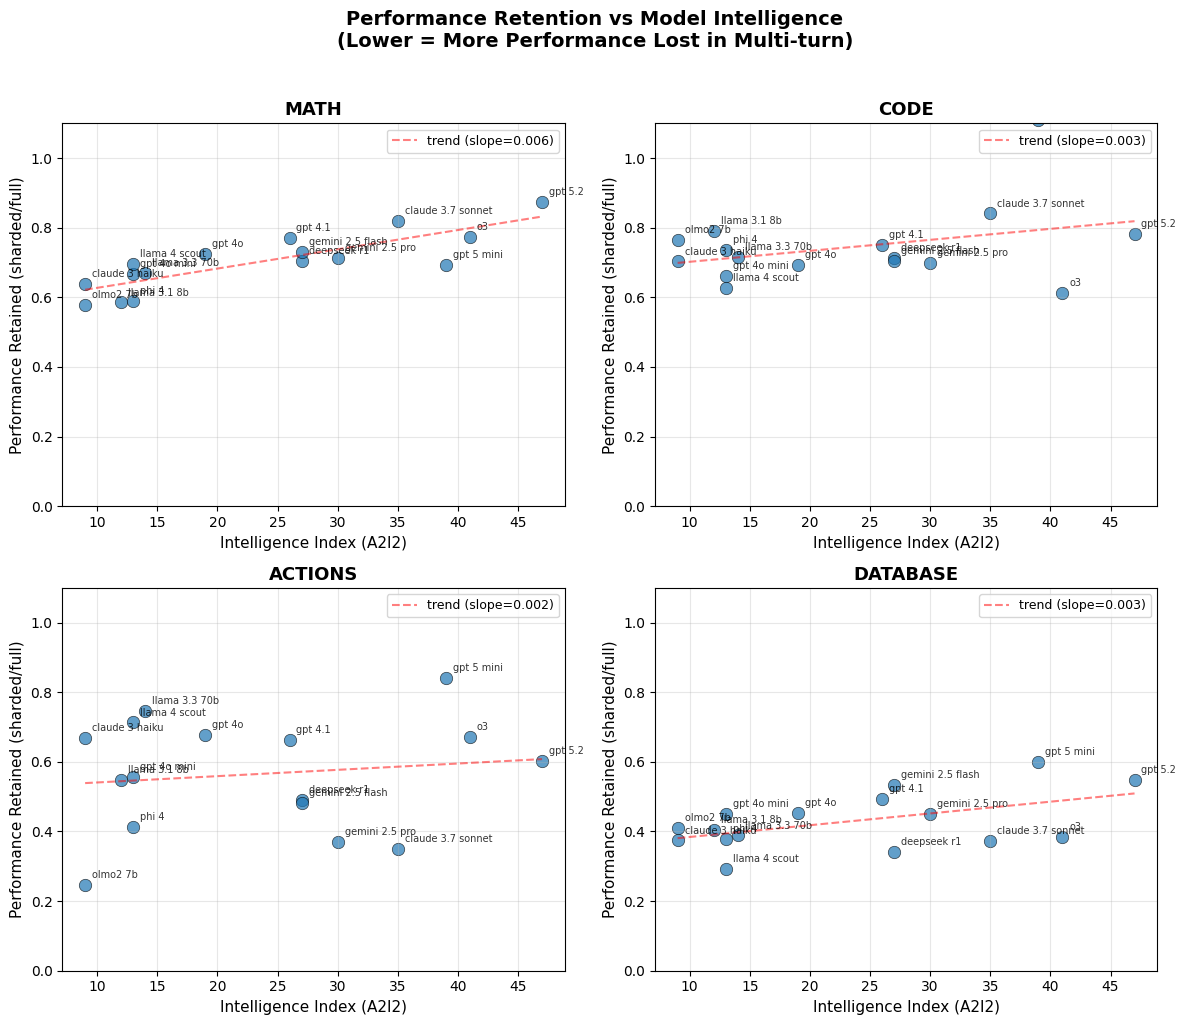

In [5]:
# Create 2x2 subplot figure for each task category
fig, axes = plt.subplots(2, 2, figsize=(12, 10))
axes = axes.flatten()

for ax, task in zip(axes, tasks_of_interest):
    task_df = df[df["task"] == task]
    
    # Plot scatter points
    ax.scatter(task_df["intelligence"], task_df["proportion_retained"], 
               s=80, alpha=0.7, edgecolors='black', linewidth=0.5)
    
    # Add model labels
    for _, row in task_df.iterrows():
        ax.annotate(row["model"].replace("_", " "), 
                    (row["intelligence"], row["proportion_retained"]),
                    fontsize=7, alpha=0.8,
                    xytext=(5, 5), textcoords='offset points')
    
    # Add trend line
    z = np.polyfit(task_df["intelligence"], task_df["proportion_retained"], 1)
    p = np.poly1d(z)
    x_line = np.linspace(task_df["intelligence"].min(), task_df["intelligence"].max(), 100)
    ax.plot(x_line, p(x_line), "r--", alpha=0.5, label=f"trend (slope={z[0]:.3f})")
    
    ax.set_xlabel("Intelligence Index (A2I2)", fontsize=11)
    ax.set_ylabel("Performance Retained (sharded/full)", fontsize=11)
    ax.set_title(f"{task.upper()}", fontsize=13, fontweight='bold')
    ax.legend(loc='best', fontsize=9)
    ax.grid(True, alpha=0.3)
    ax.set_ylim(0, 1.1)

plt.suptitle("Performance Retention vs Model Intelligence\n(Lower = More Performance Lost in Multi-turn)", 
             fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig("performance_vs_intelligence.png", dpi=150, bbox_inches='tight')
plt.show()

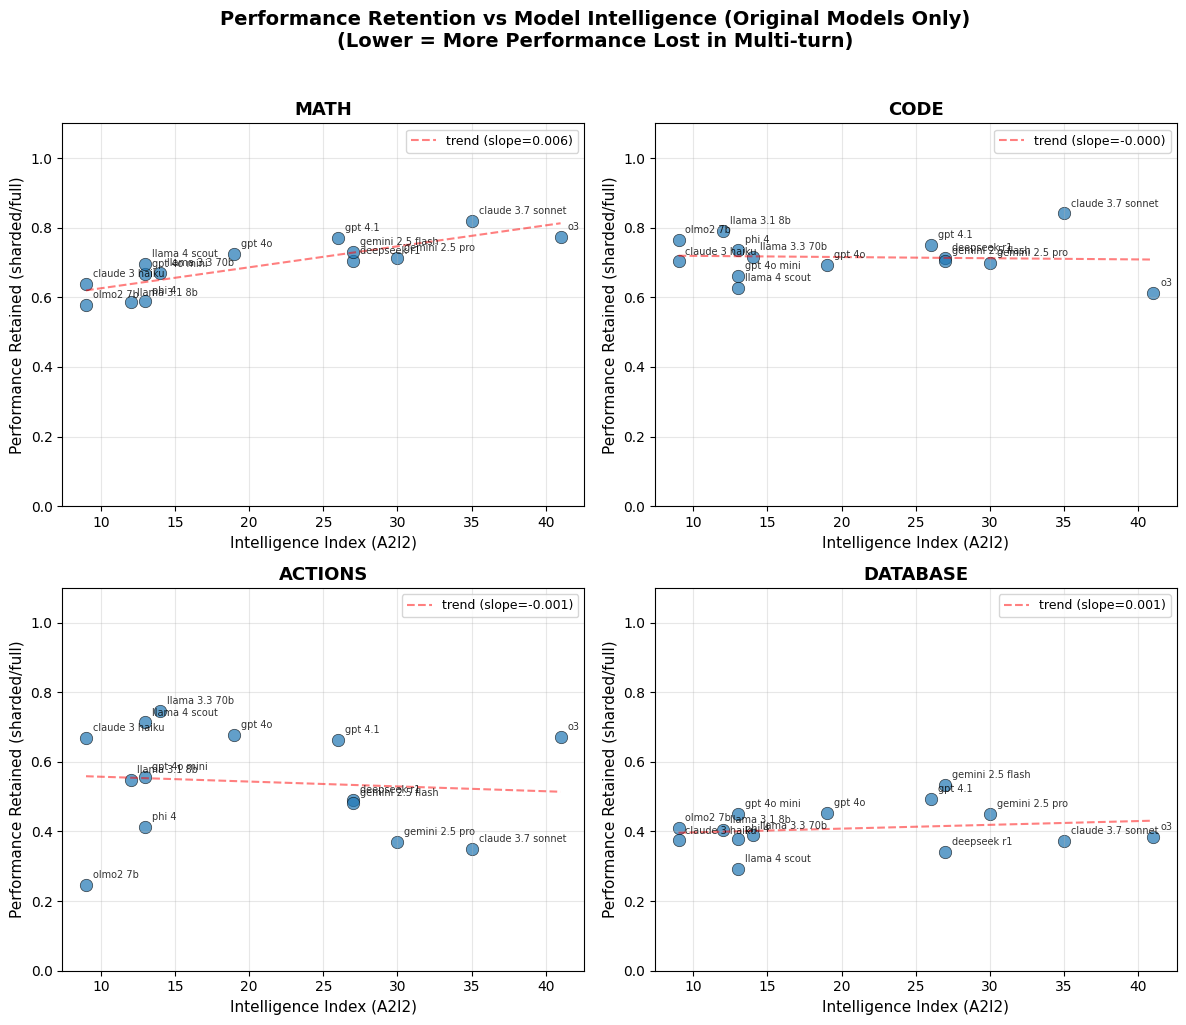

In [6]:
# Same plot WITHOUT ad-hoc additions (gpt_5_mini, gpt_5.2)
adhoc_models = {"gpt_5_mini", "gpt_5.2"}
df_original = df[~df["model"].isin(adhoc_models)]

fig, axes = plt.subplots(2, 2, figsize=(12, 10))
axes = axes.flatten()

for ax, task in zip(axes, tasks_of_interest):
    task_df = df_original[df_original["task"] == task]
    
    # Plot scatter points
    ax.scatter(task_df["intelligence"], task_df["proportion_retained"], 
               s=80, alpha=0.7, edgecolors='black', linewidth=0.5)
    
    # Add model labels
    for _, row in task_df.iterrows():
        ax.annotate(row["model"].replace("_", " "), 
                    (row["intelligence"], row["proportion_retained"]),
                    fontsize=7, alpha=0.8,
                    xytext=(5, 5), textcoords='offset points')
    
    # Add trend line
    z = np.polyfit(task_df["intelligence"], task_df["proportion_retained"], 1)
    p = np.poly1d(z)
    x_line = np.linspace(task_df["intelligence"].min(), task_df["intelligence"].max(), 100)
    ax.plot(x_line, p(x_line), "r--", alpha=0.5, label=f"trend (slope={z[0]:.3f})")
    
    ax.set_xlabel("Intelligence Index (A2I2)", fontsize=11)
    ax.set_ylabel("Performance Retained (sharded/full)", fontsize=11)
    ax.set_title(f"{task.upper()}", fontsize=13, fontweight='bold')
    ax.legend(loc='best', fontsize=9)
    ax.grid(True, alpha=0.3)
    ax.set_ylim(0, 1.1)

plt.suptitle("Performance Retention vs Model Intelligence (Original Models Only)\n(Lower = More Performance Lost in Multi-turn)", 
             fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig("performance_vs_intelligence_original.png", dpi=150, bbox_inches='tight')
plt.show()

In [7]:
# =============================================================================
# NEW DATA: Load results from sota_model_results.csv
# =============================================================================
from pathlib import Path

res_csv = Path.cwd().parent / "data/sota_model_results.csv"
df_sota = pd.read_csv(res_csv)

# a2i2 values for new GPT-5 family models (base models)
# Chat variants will use the same index as their base model
gpt5_a2i2 = {
    "gpt-5-mini": 39,
    "gpt-5": 42,
    "gpt-5.1": 44,  # interpolated - not on Artificial Analysis
    "gpt-5.2": 47,
}

# Map chat variants to base model a2i2 values
def get_a2i2(model_name):
    """Get a2i2 value, mapping chat variants to base model."""
    base_name = model_name.replace("-chat", "")
    return gpt5_a2i2.get(base_name)

df_sota.head()

,task,assistant_model,conv_type,n_convs,avg_score_cond,accuracy_cond,n_with_score,n_with_is_correct,avg_score_all,accuracy_all,n_missing_eval,n_both_present,n_mismatch_both_present,missing_eval_rate,mismatch_rate_among_both_present
0,actions,gpt-5,full,105,0.927835,0.857143,97,105,0.857143,0.857143,0,97,0,0.0,0.0
1,actions,gpt-5,sharded,105,0.561905,0.561905,105,105,0.561905,0.561905,0,105,0,0.0,0.0
2,actions,gpt-5-chat,full,105,0.971429,0.971429,105,105,0.971429,0.971429,0,105,0,0.0,0.0
3,actions,gpt-5-chat,sharded,104,0.757282,0.750000,103,104,0.750000,0.750000,0,103,0,0.0,0.0
4,actions,gpt-5-mini,full,105,0.885417,0.809524,96,105,0.809524,0.809524,0,96,0,0.0,0.0


In [8]:
# Process new CSV data to get proportion retained
# Pivot to get full and sharded side by side
df_pivot = df_sota.pivot_table(
    index=["task", "assistant_model"], 
    columns="conv_type", 
    values="accuracy_all"
).reset_index()

# Calculate proportion retained
df_pivot["proportion_retained"] = df_pivot["sharded"] / df_pivot["full"]
df_pivot["intelligence"] = df_pivot["assistant_model"].apply(get_a2i2)

# Rename for consistency
df_gpt5 = df_pivot.rename(columns={"assistant_model": "model"})
df_gpt5 = df_gpt5[df_gpt5["intelligence"].notna()]  # only models with a2i2 values

df_gpt5

conv_type,task,model,full,sharded,proportion_retained,intelligence
0,actions,gpt-5,0.857143,0.561905,0.655556,42
1,actions,gpt-5-chat,0.971429,0.750000,0.772059,42
2,actions,gpt-5-mini,0.809524,0.557692,0.688914,39
3,actions,gpt-5.1,0.676190,0.572816,0.847122,44
4,actions,gpt-5.1-chat,0.914286,0.576923,0.631010,44
5,actions,gpt-5.2,0.895238,0.300971,0.336191,47
6,actions,gpt-5.2-chat,0.819048,0.466019,0.568977,47
7,code,gpt-5,0.290000,0.584615,2.015915,42
8,code,gpt-5-chat,0.960000,0.783505,0.816151,42
9,code,gpt-5-mini,0.440000,0.344444,0.782828,39


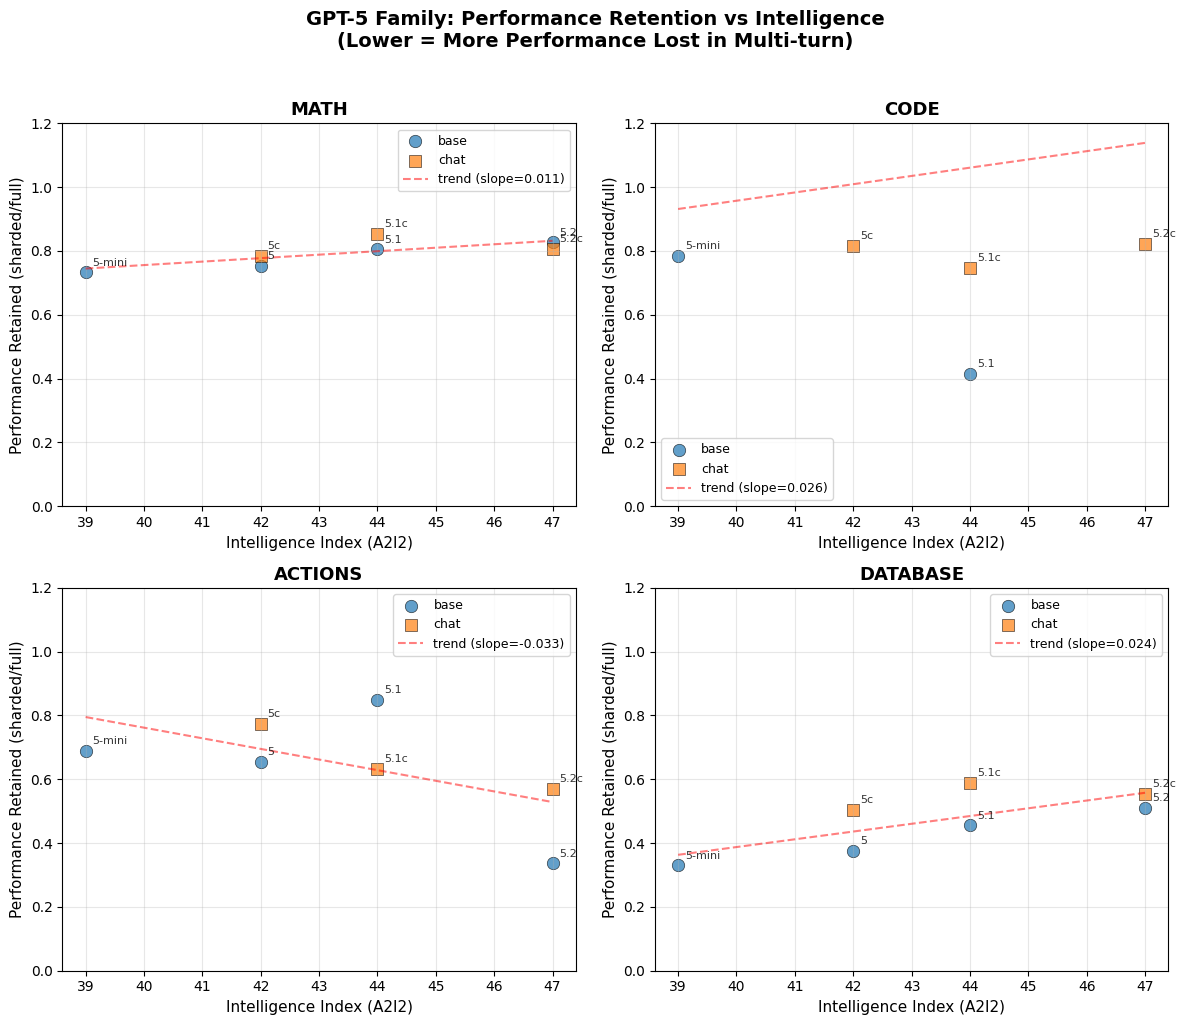

In [9]:
# =============================================================================
# FIGURE 1: GPT-5 Family Models Only
# =============================================================================
fig, axes = plt.subplots(2, 2, figsize=(12, 10))
axes = axes.flatten()

for ax, task in zip(axes, tasks_of_interest):
    task_df = df_gpt5[df_gpt5["task"] == task]
    
    # Separate base models and chat models for different markers
    base_mask = ~task_df["model"].str.contains("-chat")
    chat_mask = task_df["model"].str.contains("-chat")
    
    # Plot base models (circles)
    base_df = task_df[base_mask]
    ax.scatter(base_df["intelligence"], base_df["proportion_retained"], 
               s=80, alpha=0.7, edgecolors='black', linewidth=0.5, 
               label="base", marker='o')
    
    # Plot chat models (squares)
    chat_df = task_df[chat_mask]
    ax.scatter(chat_df["intelligence"], chat_df["proportion_retained"], 
               s=80, alpha=0.7, edgecolors='black', linewidth=0.5,
               label="chat", marker='s')
    
    # Add model labels
    for _, row in task_df.iterrows():
        label = row["model"].replace("gpt-", "").replace("-chat", "c")
        ax.annotate(label, 
                    (row["intelligence"], row["proportion_retained"]),
                    fontsize=8, alpha=0.8,
                    xytext=(5, 5), textcoords='offset points')
    
    # Add trend line (all points)
    if len(task_df) > 1:
        z = np.polyfit(task_df["intelligence"], task_df["proportion_retained"], 1)
        p = np.poly1d(z)
        x_line = np.linspace(task_df["intelligence"].min(), task_df["intelligence"].max(), 100)
        ax.plot(x_line, p(x_line), "r--", alpha=0.5, label=f"trend (slope={z[0]:.3f})")
    
    ax.set_xlabel("Intelligence Index (A2I2)", fontsize=11)
    ax.set_ylabel("Performance Retained (sharded/full)", fontsize=11)
    ax.set_title(f"{task.upper()}", fontsize=13, fontweight='bold')
    ax.legend(loc='best', fontsize=9)
    ax.grid(True, alpha=0.3)
    ax.set_ylim(0, 1.2)

plt.suptitle("GPT-5 Family: Performance Retention vs Intelligence\n(Lower = More Performance Lost in Multi-turn)", 
             fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig("performance_vs_intelligence_gpt5_family.png", dpi=150, bbox_inches='tight')
plt.show()

In [10]:
# =============================================================================
# FIGURE 2: All Models Combined (Original + New GPT-5 Family)
# =============================================================================

# Get original data WITHOUT old ad-hoc gpt-5 entries
adhoc_models_old = {"gpt_5_mini", "gpt_5.2"}
df_original_clean = df[~df["model"].isin(adhoc_models_old)].copy()

# Prepare GPT-5 data to match format (convert accuracy to percentage scale isn't needed since we use proportion)
df_gpt5_clean = df_gpt5[["model", "task", "intelligence", "full", "sharded", "proportion_retained"]].copy()

# Combine dataframes
df_combined = pd.concat([df_original_clean, df_gpt5_clean], ignore_index=True)

# Mark source for different styling
df_combined["source"] = df_combined["model"].apply(
    lambda x: "gpt5" if x.startswith("gpt-5") else "original"
)

print(f"Total data points: {len(df_combined)}")
print(f"Original models: {df_combined[df_combined['source'] == 'original']['model'].nunique()}")
print(f"GPT-5 family models: {df_combined[df_combined['source'] == 'gpt5']['model'].nunique()}")

Total data points: 84
Original models: 14
GPT-5 family models: 7


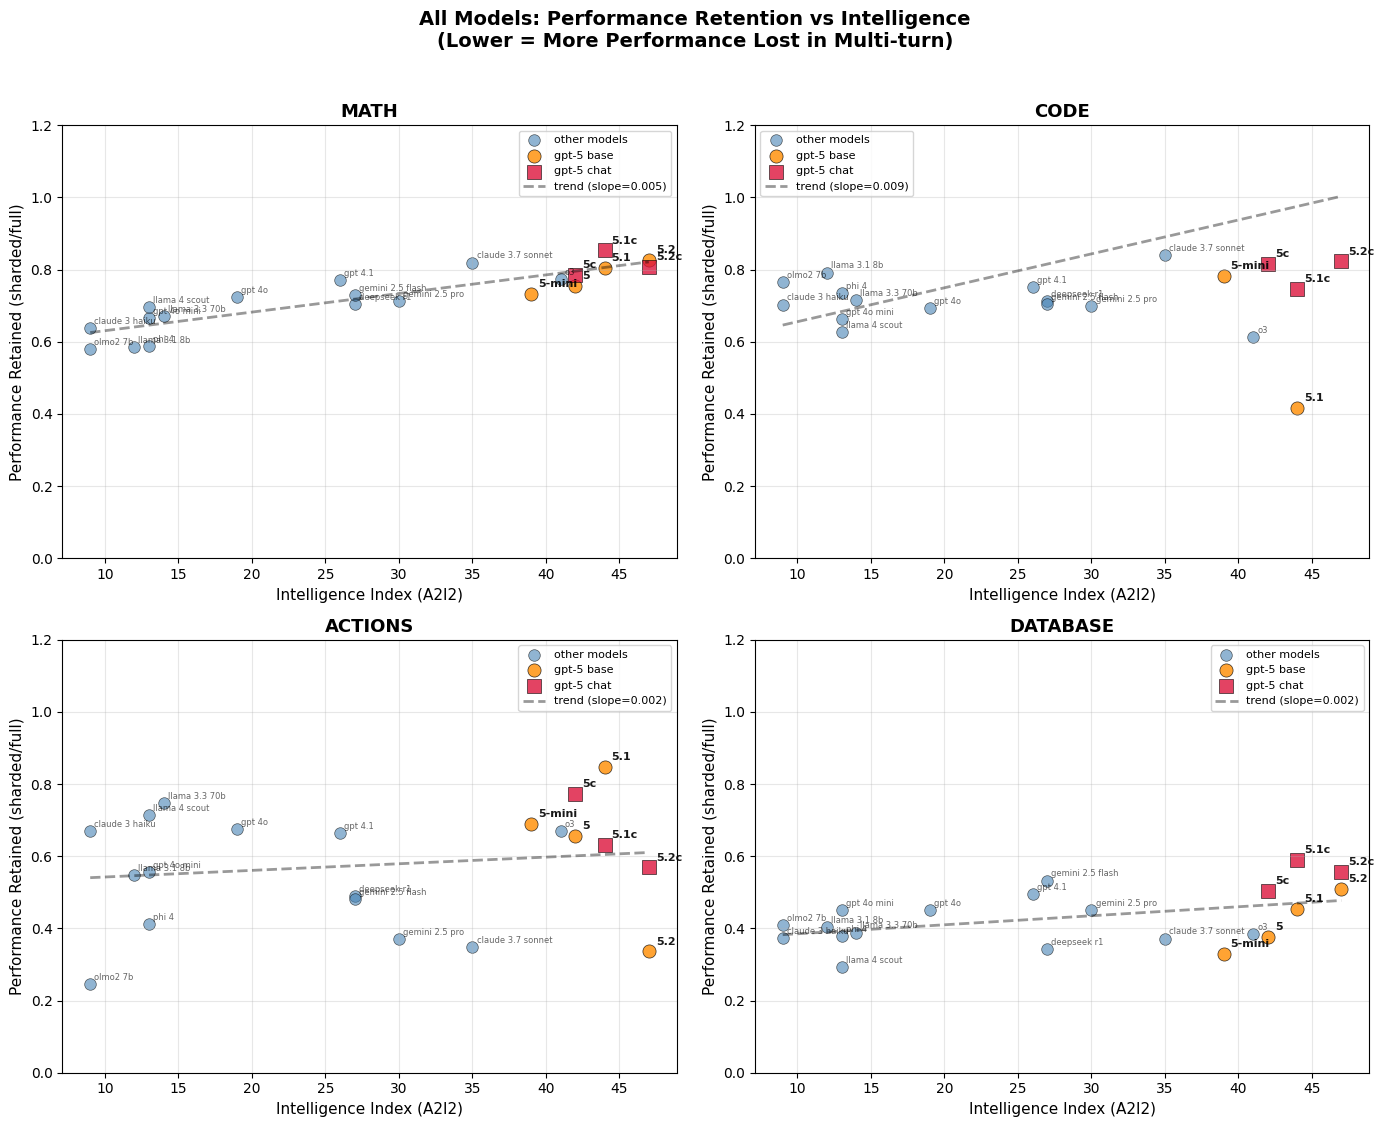

In [11]:
# Plot all models combined
fig, axes = plt.subplots(2, 2, figsize=(14, 11))
axes = axes.flatten()

for ax, task in zip(axes, tasks_of_interest):
    task_df = df_combined[df_combined["task"] == task]
    
    # Separate by source
    orig_df = task_df[task_df["source"] == "original"]
    gpt5_df = task_df[task_df["source"] == "gpt5"]
    
    # Plot original models (blue circles)
    ax.scatter(orig_df["intelligence"], orig_df["proportion_retained"], 
               s=70, alpha=0.6, edgecolors='black', linewidth=0.5, 
               color='steelblue', label="other models", marker='o')
    
    # Plot GPT-5 family (orange/red, distinguish base vs chat)
    gpt5_base = gpt5_df[~gpt5_df["model"].str.contains("-chat")]
    gpt5_chat = gpt5_df[gpt5_df["model"].str.contains("-chat")]
    
    ax.scatter(gpt5_base["intelligence"], gpt5_base["proportion_retained"], 
               s=90, alpha=0.8, edgecolors='black', linewidth=0.5,
               color='darkorange', label="gpt-5 base", marker='o')
    ax.scatter(gpt5_chat["intelligence"], gpt5_chat["proportion_retained"], 
               s=90, alpha=0.8, edgecolors='black', linewidth=0.5,
               color='crimson', label="gpt-5 chat", marker='s')
    
    # Add labels for original models (smaller font)
    for _, row in orig_df.iterrows():
        ax.annotate(row["model"].replace("_", " "), 
                    (row["intelligence"], row["proportion_retained"]),
                    fontsize=6, alpha=0.6,
                    xytext=(3, 3), textcoords='offset points')
    
    # Add labels for GPT-5 models (larger font)
    for _, row in gpt5_df.iterrows():
        label = row["model"].replace("gpt-", "").replace("-chat", "c")
        ax.annotate(label, 
                    (row["intelligence"], row["proportion_retained"]),
                    fontsize=8, alpha=0.9, fontweight='bold',
                    xytext=(5, 5), textcoords='offset points')
    
    # Add trend line (all points)
    if len(task_df) > 1:
        z = np.polyfit(task_df["intelligence"], task_df["proportion_retained"], 1)
        p = np.poly1d(z)
        x_line = np.linspace(task_df["intelligence"].min(), task_df["intelligence"].max(), 100)
        ax.plot(x_line, p(x_line), "k--", alpha=0.4, linewidth=2, label=f"trend (slope={z[0]:.3f})")
    
    ax.set_xlabel("Intelligence Index (A2I2)", fontsize=11)
    ax.set_ylabel("Performance Retained (sharded/full)", fontsize=11)
    ax.set_title(f"{task.upper()}", fontsize=13, fontweight='bold')
    ax.legend(loc='best', fontsize=8)
    ax.grid(True, alpha=0.3)
    ax.set_ylim(0, 1.2)

plt.suptitle("All Models: Performance Retention vs Intelligence\n(Lower = More Performance Lost in Multi-turn)", 
             fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig("performance_vs_intelligence_all_models.png", dpi=150, bbox_inches='tight')
plt.show()

In [12]:
# =============================================================================
# Normalize data to 0-1 scale for combined plotting
# =============================================================================

# Original data is in percentages (0-100), GPT-5 data is in fractions (0-1)
# Normalize original data to 0-1
df_original_normalized = df_original_clean.copy()
df_original_normalized["full"] = df_original_normalized["full"] / 100
df_original_normalized["sharded"] = df_original_normalized["sharded"] / 100

# GPT-5 data is already in 0-1
df_gpt5_normalized = df_gpt5_clean.copy()

# Combine normalized dataframes
df_combined_norm = pd.concat([df_original_normalized, df_gpt5_normalized], ignore_index=True)
df_combined_norm["source"] = df_combined_norm["model"].apply(
    lambda x: "gpt5" if x.startswith("gpt-5") else "original"
)

print("Sample of normalized data:")
df_combined_norm.sample(5)

Sample of normalized data:


,model,task,intelligence,full,sharded,proportion_retained,source
46,gemini_2.5_flash,actions,27,0.884000,0.426000,0.481900,original
31,o3,database,41,0.920000,0.354000,0.384783,original
13,gpt_4o_mini,code,13,0.759000,0.503000,0.662714,original
76,gpt-5.2-chat,database,47,0.934579,0.518868,0.555189,gpt5
0,llama_3.1_8b,math,12,0.639000,0.374000,0.585290,original


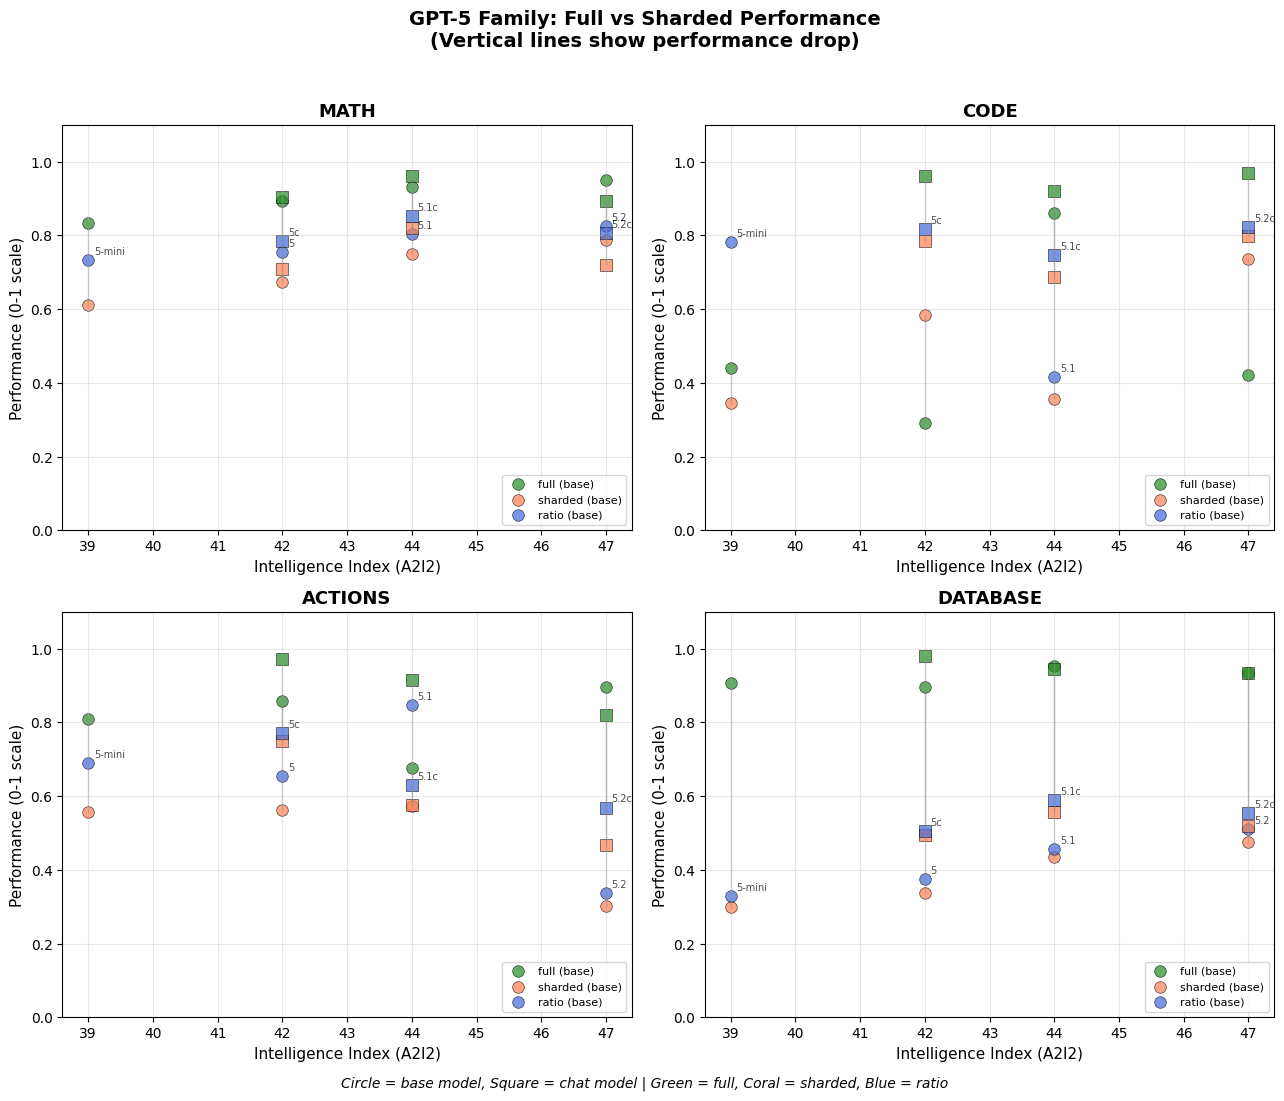

In [13]:
# =============================================================================
# FIGURE: GPT-5 Family - Full, Sharded, and Ratio
# =============================================================================
fig, axes = plt.subplots(2, 2, figsize=(13, 11))
axes = axes.flatten()

colors = {'full': 'forestgreen', 'sharded': 'coral', 'ratio': 'royalblue'}
markers = {'base': 'o', 'chat': 's'}

for ax, task in zip(axes, tasks_of_interest):
    task_df = df_gpt5_normalized[df_gpt5_normalized["task"] == task].copy()
    
    # Separate base and chat
    task_df["variant"] = task_df["model"].apply(lambda x: "chat" if "-chat" in x else "base")
    
    for variant in ["base", "chat"]:
        vdf = task_df[task_df["variant"] == variant]
        marker = markers[variant]
        
        # Plot full performance (green)
        ax.scatter(vdf["intelligence"], vdf["full"], 
                   s=70, alpha=0.7, edgecolors='black', linewidth=0.5,
                   color=colors['full'], marker=marker,
                   label=f"full ({variant})" if variant == "base" else None)
        
        # Plot sharded performance (coral/red)
        ax.scatter(vdf["intelligence"], vdf["sharded"], 
                   s=70, alpha=0.7, edgecolors='black', linewidth=0.5,
                   color=colors['sharded'], marker=marker,
                   label=f"sharded ({variant})" if variant == "base" else None)
        
        # Plot ratio (blue) - on secondary y-axis conceptually but keep on same scale
        ax.scatter(vdf["intelligence"], vdf["proportion_retained"], 
                   s=70, alpha=0.7, edgecolors='black', linewidth=0.5,
                   color=colors['ratio'], marker=marker,
                   label=f"ratio ({variant})" if variant == "base" else None)
        
        # Connect full->sharded with lines for each model
        for _, row in vdf.iterrows():
            ax.plot([row["intelligence"], row["intelligence"]], 
                    [row["full"], row["sharded"]], 
                    color='gray', alpha=0.3, linewidth=1, linestyle='-')
    
    # Add model labels (only for ratio points to reduce clutter)
    for _, row in task_df.iterrows():
        label = row["model"].replace("gpt-", "").replace("-chat", "c")
        ax.annotate(label, (row["intelligence"], row["proportion_retained"]),
                    fontsize=7, alpha=0.7, xytext=(4, 4), textcoords='offset points')
    
    ax.set_xlabel("Intelligence Index (A2I2)", fontsize=11)
    ax.set_ylabel("Performance (0-1 scale)", fontsize=11)
    ax.set_title(f"{task.upper()}", fontsize=13, fontweight='bold')
    ax.grid(True, alpha=0.3)
    ax.set_ylim(0, 1.1)
    ax.legend(loc='lower right', fontsize=8)

# Add legend explanation
fig.text(0.5, 0.02, "Circle = base model, Square = chat model | Green = full, Coral = sharded, Blue = ratio", 
         ha='center', fontsize=10, style='italic')

plt.suptitle("GPT-5 Family: Full vs Sharded Performance\n(Vertical lines show performance drop)", 
             fontsize=14, fontweight='bold', y=1.0)
plt.tight_layout(rect=[0, 0.03, 1, 0.98])
plt.savefig("gpt5_full_sharded_ratio.png", dpi=150, bbox_inches='tight')
plt.show()

/var/folders/r1/ml049521017bkv2610b6fhbc0000gn/T/ipykernel_353/2881218118.py:37: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  gpt5_df["variant"] = gpt5_df["model"].apply(lambda x: "chat" if "-chat" in x else "base")
/var/folders/r1/ml049521017bkv2610b6fhbc0000gn/T/ipykernel_353/2881218118.py:37: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  gpt5_df["variant"] = gpt5_df["model"].apply(lambda x: "chat" if "-chat" in x else "base")
/var/folders/r1/ml049521017bkv2610b6fhbc0000gn/T/ipykernel_353/2881218118.py:3

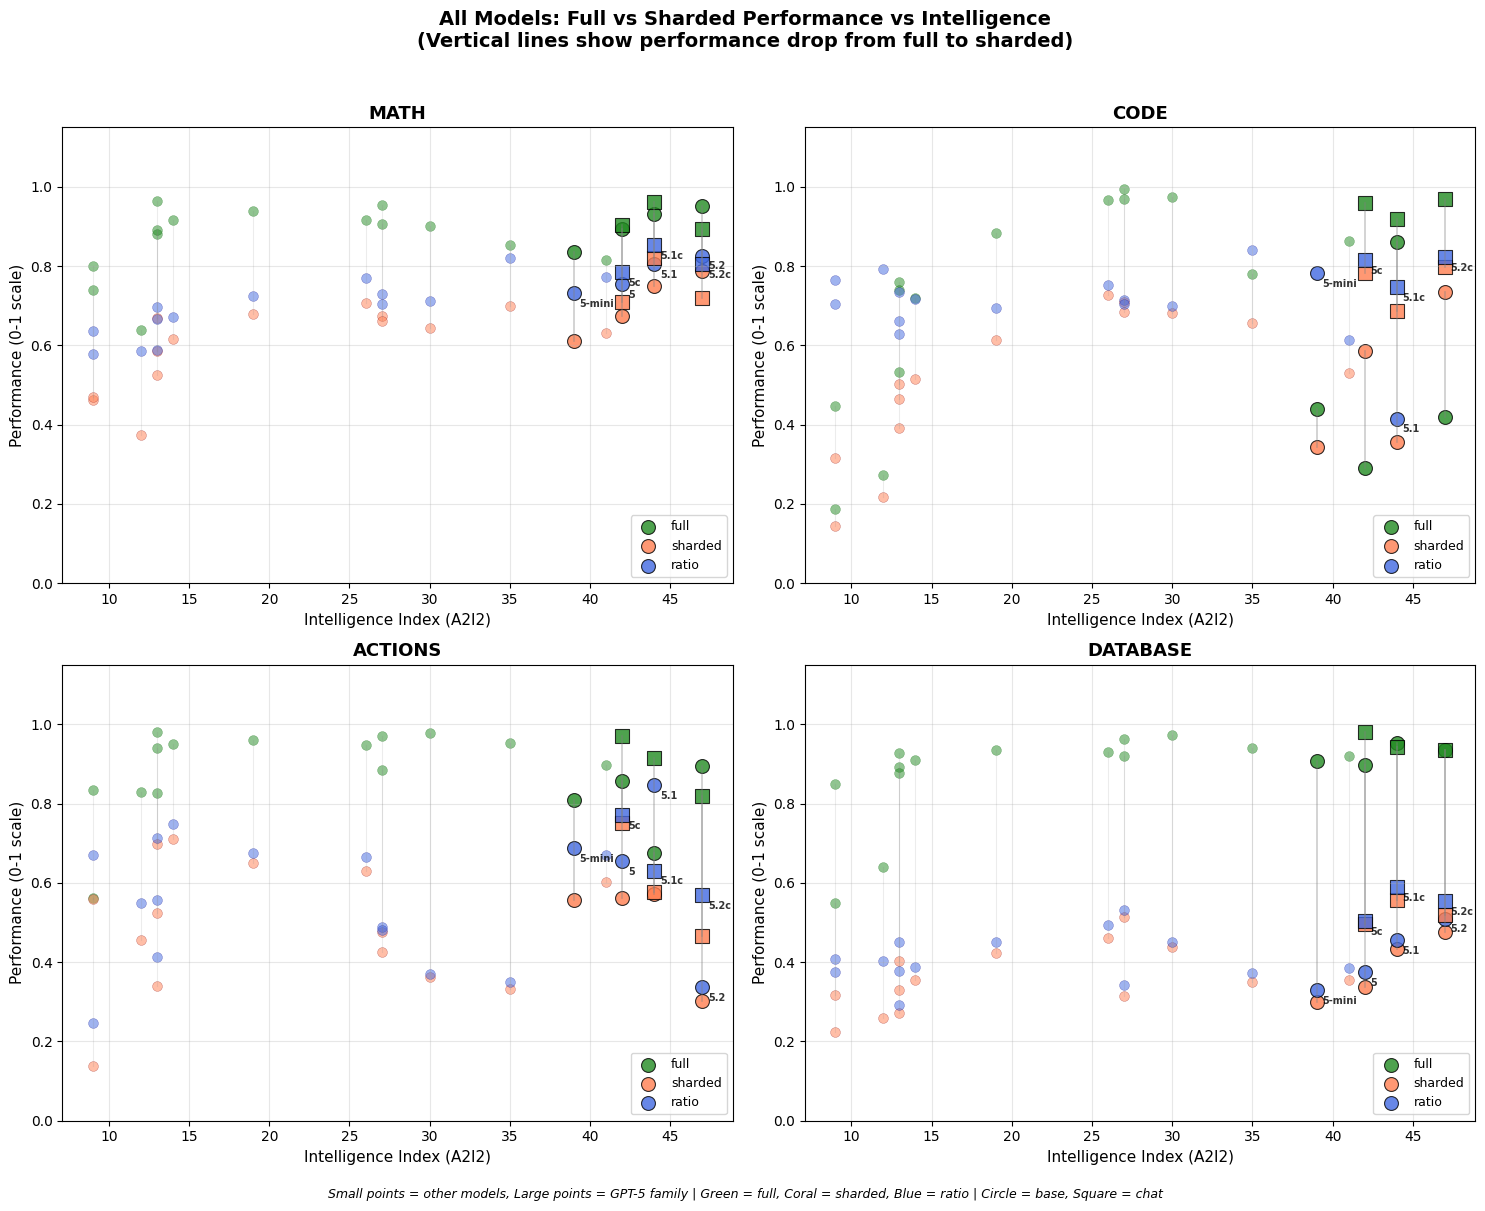

In [14]:
# =============================================================================
# FIGURE: All Models - Full, Sharded, and Ratio
# =============================================================================
fig, axes = plt.subplots(2, 2, figsize=(15, 12))
axes = axes.flatten()

colors = {'full': 'forestgreen', 'sharded': 'coral', 'ratio': 'royalblue'}

for ax, task in zip(axes, tasks_of_interest):
    task_df = df_combined_norm[df_combined_norm["task"] == task].copy()
    
    # Separate original vs GPT-5
    orig_df = task_df[task_df["source"] == "original"]
    gpt5_df = task_df[task_df["source"] == "gpt5"]
    
    # --- Original models (smaller, lighter) ---
    # Full (green circles)
    ax.scatter(orig_df["intelligence"], orig_df["full"], 
               s=50, alpha=0.5, edgecolors='darkgreen', linewidth=0.3,
               color=colors['full'], marker='o')
    # Sharded (coral circles)
    ax.scatter(orig_df["intelligence"], orig_df["sharded"], 
               s=50, alpha=0.5, edgecolors='darkred', linewidth=0.3,
               color=colors['sharded'], marker='o')
    # Ratio (blue circles)
    ax.scatter(orig_df["intelligence"], orig_df["proportion_retained"], 
               s=50, alpha=0.5, edgecolors='darkblue', linewidth=0.3,
               color=colors['ratio'], marker='o')
    
    # Connect full->sharded for original
    for _, row in orig_df.iterrows():
        ax.plot([row["intelligence"], row["intelligence"]], 
                [row["full"], row["sharded"]], 
                color='gray', alpha=0.15, linewidth=0.8)
    
    # --- GPT-5 models (larger, bolder) ---
    gpt5_df["variant"] = gpt5_df["model"].apply(lambda x: "chat" if "-chat" in x else "base")
    
    for variant in ["base", "chat"]:
        vdf = gpt5_df[gpt5_df["variant"] == variant]
        marker = 'o' if variant == "base" else 's'
        
        # Full (green)
        ax.scatter(vdf["intelligence"], vdf["full"], 
                   s=100, alpha=0.8, edgecolors='black', linewidth=0.8,
                   color=colors['full'], marker=marker,
                   label=f"full" if variant == "base" else None)
        # Sharded (coral)
        ax.scatter(vdf["intelligence"], vdf["sharded"], 
                   s=100, alpha=0.8, edgecolors='black', linewidth=0.8,
                   color=colors['sharded'], marker=marker,
                   label=f"sharded" if variant == "base" else None)
        # Ratio (blue)
        ax.scatter(vdf["intelligence"], vdf["proportion_retained"], 
                   s=100, alpha=0.8, edgecolors='black', linewidth=0.8,
                   color=colors['ratio'], marker=marker,
                   label=f"ratio" if variant == "base" else None)
        
        # Connect full->sharded
        for _, row in vdf.iterrows():
            ax.plot([row["intelligence"], row["intelligence"]], 
                    [row["full"], row["sharded"]], 
                    color='gray', alpha=0.4, linewidth=1.2)
    
    # Labels for GPT-5 models only (at ratio position)
    for _, row in gpt5_df.iterrows():
        label = row["model"].replace("gpt-", "").replace("-chat", "c")
        ax.annotate(label, (row["intelligence"], row["proportion_retained"]),
                    fontsize=7, alpha=0.8, fontweight='bold',
                    xytext=(4, -10), textcoords='offset points')
    
    ax.set_xlabel("Intelligence Index (A2I2)", fontsize=11)
    ax.set_ylabel("Performance (0-1 scale)", fontsize=11)
    ax.set_title(f"{task.upper()}", fontsize=13, fontweight='bold')
    ax.grid(True, alpha=0.3)
    ax.set_ylim(0, 1.15)
    ax.legend(loc='lower right', fontsize=9)

fig.text(0.5, 0.01, 
         "Small points = other models, Large points = GPT-5 family | Green = full, Coral = sharded, Blue = ratio | Circle = base, Square = chat", 
         ha='center', fontsize=9, style='italic')

plt.suptitle("All Models: Full vs Sharded Performance vs Intelligence\n(Vertical lines show performance drop from full to sharded)", 
             fontsize=14, fontweight='bold', y=1.0)
plt.tight_layout(rect=[0, 0.025, 1, 0.98])
plt.savefig("all_models_full_sharded_ratio.png", dpi=150, bbox_inches='tight')
plt.show()

In [15]:
def plot_full_sharded_vs_intelligence(
    df_original: pd.DataFrame,
    df_gpt5: pd.DataFrame,
    tasks: list[str] | None = None,
    gpt5_mode: str = "both",  # "none", "base", "chat", "both"
    save_path: str = "full_sharded_vs_intelligence.png",
):
    """
    Scatter plot of full and sharded performance vs intelligence index,
    with separate trendlines for each.

    Parameters
    ----------
    df_original : DataFrame
        Normalized original model data with columns:
        model, task, intelligence, full, sharded.
    df_gpt5 : DataFrame
        Normalized GPT-5 family data with the same columns.
    tasks : list of str, optional
        Tasks to include. Defaults to ["math", "code", "actions", "database"].
    gpt5_mode : str
        Which GPT-5 variants to include:
        "none"  – exclude all GPT-5 models
        "base"  – include only base models (no -chat suffix)
        "chat"  – include only chat models (-chat suffix)
        "both"  – include both base and chat variants
    save_path : str
        File path for the saved figure.
    """
    if tasks is None:
        tasks = ["math", "code", "actions", "database"]

    # --- assemble the dataset ------------------------------------------------
    frames = [df_original[df_original["task"].isin(tasks)].copy()]

    if gpt5_mode != "none":
        gpt5_subset = df_gpt5[df_gpt5["task"].isin(tasks)].copy()
        is_chat = gpt5_subset["model"].str.contains("-chat")
        if gpt5_mode == "base":
            gpt5_subset = gpt5_subset[~is_chat]
        elif gpt5_mode == "chat":
            gpt5_subset = gpt5_subset[is_chat]
        # "both" keeps everything
        frames.append(gpt5_subset)

    df_plot = pd.concat(frames, ignore_index=True)

    # --- colours & layout ----------------------------------------------------
    color_full = "forestgreen"
    color_sharded = "coral"
    ncols = min(len(tasks), 2)
    nrows = (len(tasks) + ncols - 1) // ncols
    fig, axes = plt.subplots(nrows, ncols, figsize=(7 * ncols, 5.5 * nrows))
    if len(tasks) == 1:
        axes = [axes]
    else:
        axes = axes.flatten()

    for ax, task in zip(axes, tasks):
        tdf = df_plot[df_plot["task"] == task]

        # separate original vs gpt-5 for marker styling
        orig = tdf[~tdf["model"].str.startswith("gpt-5")]
        gpt5 = tdf[tdf["model"].str.startswith("gpt-5")]
        gpt5_base = gpt5[~gpt5["model"].str.contains("-chat")]
        gpt5_chat = gpt5[gpt5["model"].str.contains("-chat")]

        # -- scatter: original models (circles) --
        ax.scatter(orig["intelligence"], orig["full"],
                   s=60, alpha=0.6, color=color_full, edgecolors="black",
                   linewidth=0.4, marker="o", label="full")
        ax.scatter(orig["intelligence"], orig["sharded"],
                   s=60, alpha=0.6, color=color_sharded, edgecolors="black",
                   linewidth=0.4, marker="o", label="sharded")

        # -- scatter: gpt-5 base (circles, larger) --
        if not gpt5_base.empty:
            ax.scatter(gpt5_base["intelligence"], gpt5_base["full"],
                       s=100, alpha=0.8, color=color_full, edgecolors="black",
                       linewidth=0.8, marker="o")
            ax.scatter(gpt5_base["intelligence"], gpt5_base["sharded"],
                       s=100, alpha=0.8, color=color_sharded, edgecolors="black",
                       linewidth=0.8, marker="o")

        # -- scatter: gpt-5 chat (squares, larger) --
        if not gpt5_chat.empty:
            ax.scatter(gpt5_chat["intelligence"], gpt5_chat["full"],
                       s=100, alpha=0.8, color=color_full, edgecolors="black",
                       linewidth=0.8, marker="s")
            ax.scatter(gpt5_chat["intelligence"], gpt5_chat["sharded"],
                       s=100, alpha=0.8, color=color_sharded, edgecolors="black",
                       linewidth=0.8, marker="s")

        # -- model labels --
        for _, row in orig.iterrows():
            ax.annotate(row["model"].replace("_", " "),
                        (row["intelligence"], row["full"]),
                        fontsize=6, alpha=0.5, xytext=(3, 3),
                        textcoords="offset points")
        for _, row in gpt5.iterrows():
            label = row["model"].replace("gpt-", "").replace("-chat", "c")
            ax.annotate(label,
                        (row["intelligence"], row["full"]),
                        fontsize=7, alpha=0.8, fontweight="bold",
                        xytext=(4, 4), textcoords="offset points")

        # -- trendlines -------------------------------------------------------
        if len(tdf) > 1:
            x_range = np.linspace(tdf["intelligence"].min(),
                                  tdf["intelligence"].max(), 100)

            z_full = np.polyfit(tdf["intelligence"], tdf["full"], 1)
            ax.plot(x_range, np.poly1d(z_full)(x_range),
                    color=color_full, linestyle="--", alpha=0.6, linewidth=2,
                    label=f"full trend (slope={z_full[0]:.4f})")

            z_shard = np.polyfit(tdf["intelligence"], tdf["sharded"], 1)
            ax.plot(x_range, np.poly1d(z_shard)(x_range),
                    color=color_sharded, linestyle="--", alpha=0.6, linewidth=2,
                    label=f"sharded trend (slope={z_shard[0]:.4f})")

        ax.set_xlabel("Intelligence Index (A2I2)", fontsize=11)
        ax.set_ylabel("Performance (0–1)", fontsize=11)
        ax.set_title(task.upper(), fontsize=13, fontweight="bold")
        ax.legend(loc="best", fontsize=8)
        ax.grid(True, alpha=0.3)
        ax.set_ylim(0, 1.1)

    # hide unused axes when #tasks is odd
    for ax in axes[len(tasks):]:
        ax.set_visible(False)

    mode_label = {"none": "No GPT-5", "base": "GPT-5 Base Only",
                  "chat": "GPT-5 Chat Only", "both": "GPT-5 Base + Chat"}
    plt.suptitle(
        f"Full & Sharded Performance vs Intelligence ({mode_label[gpt5_mode]})",
        fontsize=14, fontweight="bold", y=1.02,
    )
    plt.tight_layout()
    plt.savefig(save_path, dpi=150, bbox_inches="tight")
    plt.show()
    print(f"Saved to {save_path}")

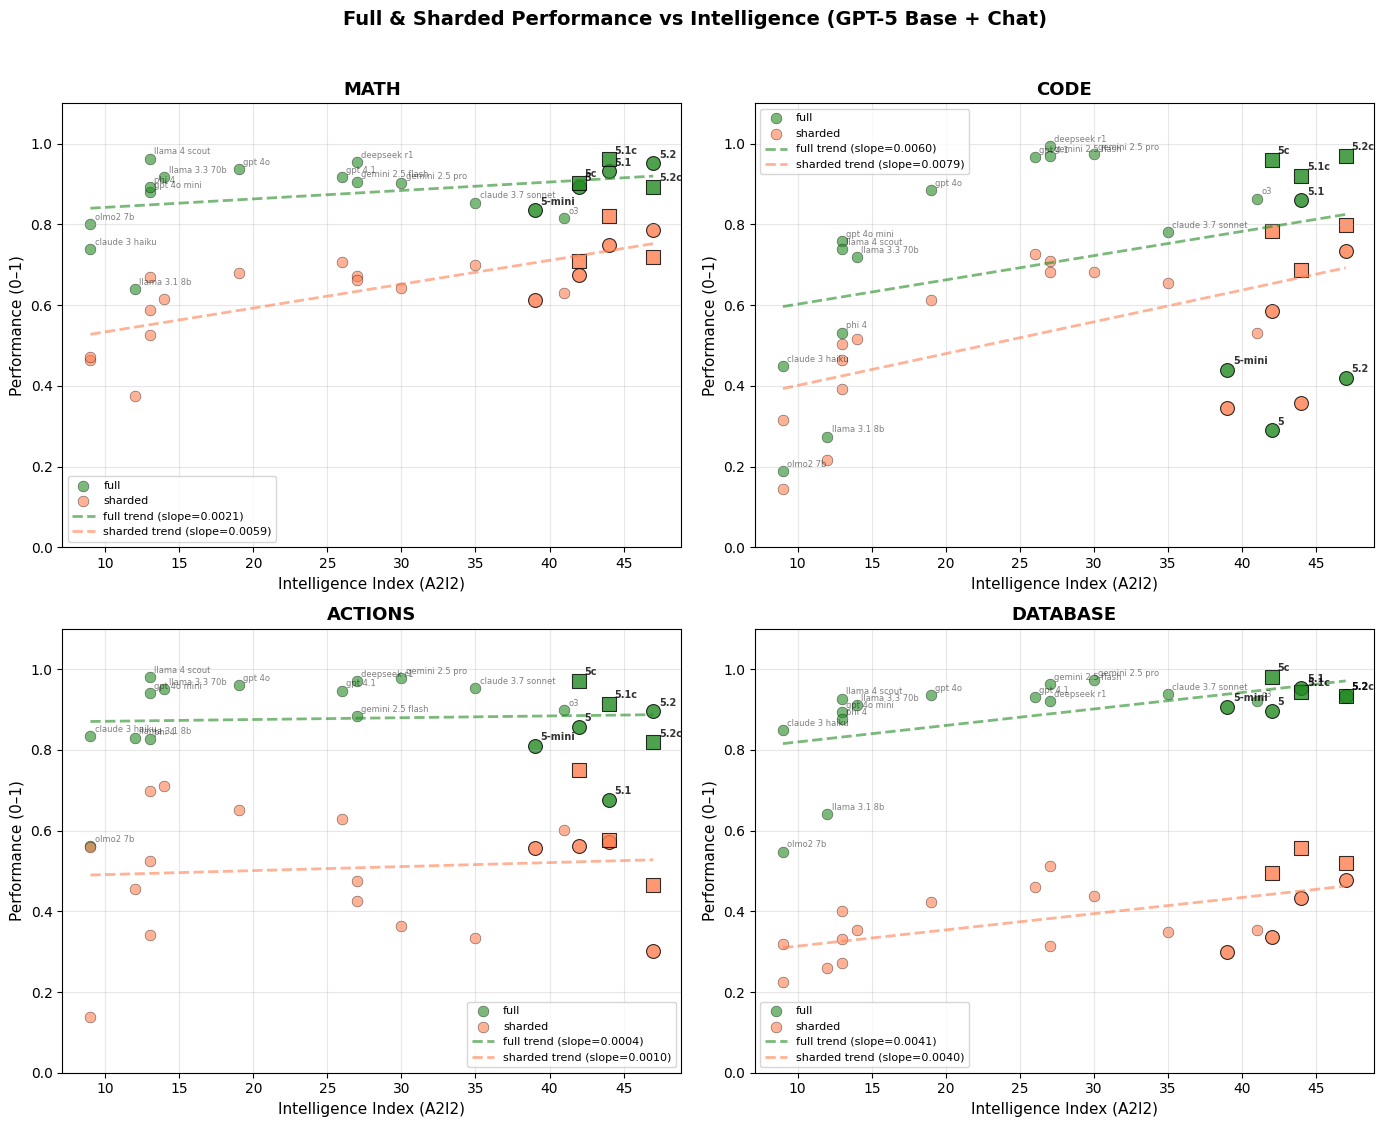

Saved to full_sharded_vs_intelligence_both2.png


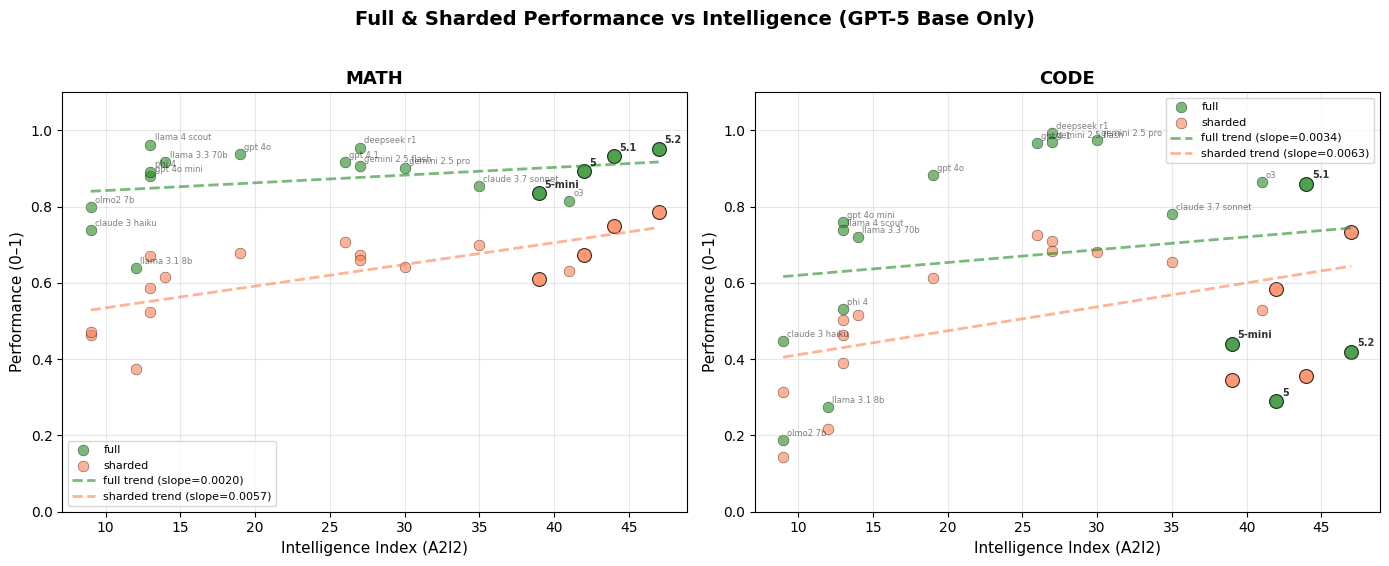

Saved to full_sharded_vs_intelligence_base_math_code2.png


In [16]:
# Example calls — adjust parameters as needed

# All models, include both GPT-5 variants, all 4 default tasks
plot_full_sharded_vs_intelligence(
    df_original_normalized, df_gpt5_normalized,
    gpt5_mode="both",
    save_path="full_sharded_vs_intelligence_both2.png",
)

# Only base GPT-5 models, subset of tasks
plot_full_sharded_vs_intelligence(
    df_original_normalized, df_gpt5_normalized,
    tasks=["math", "code"],
    gpt5_mode="base",
    save_path="full_sharded_vs_intelligence_base_math_code2.png",
)

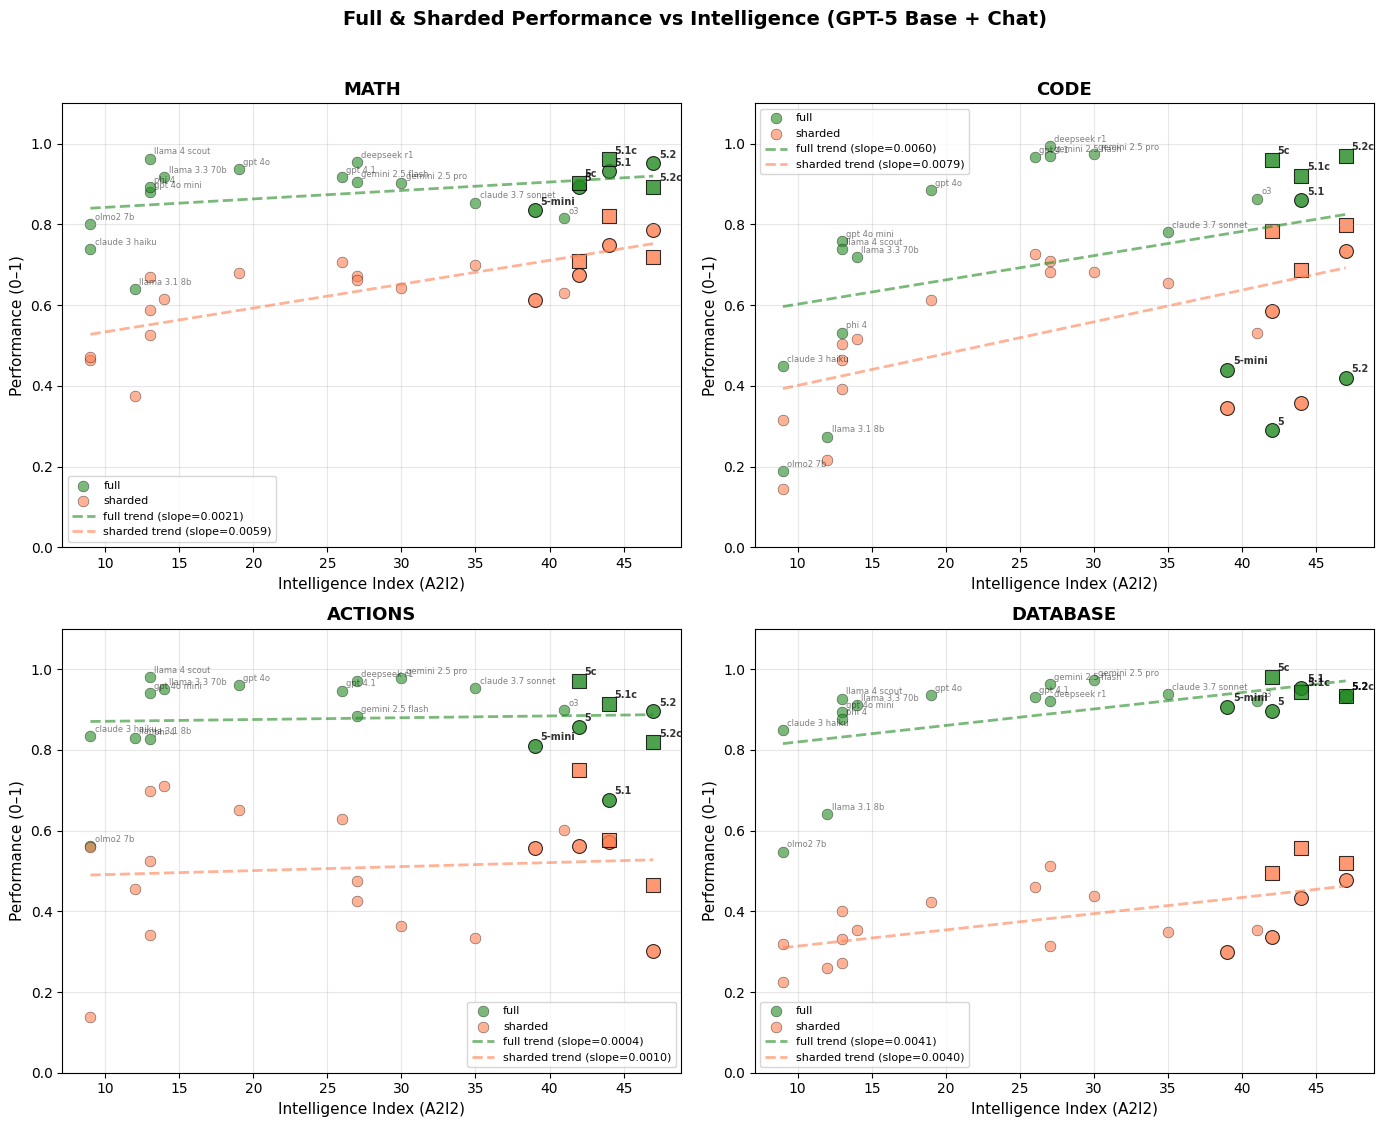

Saved to /Users/matthewho/Documents/research/ctx_editor/data/plots/both_trend_lines_all_tasks.png


In [25]:
# All models, include both GPT-5 variants, all 4 default tasks
plot_full_sharded_vs_intelligence(
    df_original_normalized, df_gpt5_normalized,
    gpt5_mode="both",
    save_path=PLOTS_FOLDER / "both_trend_lines_all_tasks.png",
)